In [352]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [353]:
%precision 3

'%.3f'

In [354]:
x_set = np.array([1, 2, 3, 4, 5, 6])

In [355]:
def f(x):
    if x in x_set:
        return x / 21
    else:
        return 0

In [356]:
X = [x_set, f]

In [357]:
X

[array([1, 2, 3, 4, 5, 6]), <function __main__.f(x)>]

In [358]:
prob = np.array([f(x_k) for x_k in x_set])

In [359]:
prob

array([0.048, 0.095, 0.143, 0.19 , 0.238, 0.286])

<BarContainer object of 6 artists>

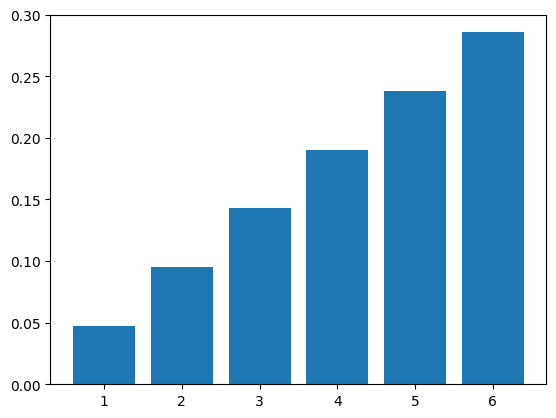

In [360]:
plt.bar(x_set, prob)

In [361]:
np.all(prob >= 0)

np.True_

확률질량함수 = 확률함수

In [362]:
def F(x):
    return np.sum([f(x_k) for x_k in x_set if x_k <= x])

In [363]:
F(3)

np.float64(0.2857142857142857)

## 확률변수의 변환
X에 2를 곱하고 3을 더한 2X + 3도 확률변수가 된다.

(X - $\bar{X})$ / $\sigma$

In [364]:
y_set = np.array([2 * x_k + 3 for x_k in x_set])

In [365]:
y_set

array([ 5,  7,  9, 11, 13, 15])

In [366]:
prob = np.array([f(x_k) for x_k in x_set])

In [367]:
prob

array([0.048, 0.095, 0.143, 0.19 , 0.238, 0.286])

In [368]:
dict(zip(y_set, prob))

{np.int64(5): np.float64(0.047619047619047616),
 np.int64(7): np.float64(0.09523809523809523),
 np.int64(9): np.float64(0.14285714285714285),
 np.int64(11): np.float64(0.19047619047619047),
 np.int64(13): np.float64(0.23809523809523808),
 np.int64(15): np.float64(0.2857142857142857)}

In [369]:
def g(y):
    x = (y-3) / 2
    return f(x)

In [370]:
Y = [y_set, g]

In [371]:
Y

[array([ 5,  7,  9, 11, 13, 15]), <function __main__.g(y)>]

In [372]:
np.array([g(y_k) for y_k in y_set])

array([0.048, 0.095, 0.143, 0.19 , 0.238, 0.286])

# 1차원 이산형 확률변수의 지표

## 기댓값
기댓값 (E(X)) = 확률변수의 평균

확률변수를 무제한 시행하여 얻어진 실현값의 평균

무제한 시행할 수 없으므로 확률변수가 취할 수 있는 값과 확률의 곱의 총합

E[X], E(X) => 두가지로 표현가능

평균내는 방법 --> 기댓값 산출 방식을 유도

기댓값으로 분산 구하는 공식 = 편차 제곱의 기댓값

$S_{xy} = {1 \over n} \sum\limits_{i = 1}^n (X_i - \bar{X})(Y_i - \bar{Y})$ = $E[(X_i - \bar{X})(Y_i - \bar{Y})]$

공분산으로 기댓값

$S_{2} = {1 \over n} \sum\limits_{i = 1}^n (X_i - \bar{X})^2 = E[(X_i - \bar{X})^2]$

In [373]:
prob

array([0.048, 0.095, 0.143, 0.19 , 0.238, 0.286])

In [374]:
x_set

array([1, 2, 3, 4, 5, 6])

In [375]:
s = 0
for i in x_set:
    s += i * prob[i-1]
print(s)

4.333333333333333


In [376]:
np.sum([x_k * f(x_k) for x_k in x_set])

np.float64(4.333333333333333)

100만(1e6)번 실행

In [377]:
sample = np.random.choice(x_set, int(1e6), p=prob)

In [378]:
sample

array([4, 5, 6, ..., 2, 4, 6])

In [379]:
np.mean(sample)

np.float64(4.334974)

In [380]:
def E_x(X):
    x_set, f = X
    return np.sum([x_k * f(x_k) for x_k in x_set])

In [381]:
E_x(X)

np.float64(4.333333333333333)

Y = 2X + 3의 기댓값을 생각해보자

g = x --> E(X)

g = 2x + 3 --> E(2X + 3)

g = 4x - 5 --> E(4X - 5)

In [382]:
X

[array([1, 2, 3, 4, 5, 6]), <function __main__.f(x)>]

In [383]:
def E(X, g=lambda x: x):
    x_set, f = X
    return sum([g(x_k)*f(x_k) for x_k in x_set])

In [384]:
E(X)

np.float64(4.333333333333333)

In [385]:
E(X, g=lambda x: 2*x + 3)

np.float64(11.666666666666664)

In [386]:
# 분산
mean = E(X)
np.sum([(x_k - mean)**2 * f(x_k) for x_k in x_set])

np.float64(2.2222222222222223)

In [387]:
def V(X, g=lambda x : x):
    x_set, f = X
    mean = E(X, g)
    return np.sum([(g(x_k) - mean)**2 * f(x_k) for x_k in x_set])

In [388]:
V(X)

np.float64(2.2222222222222223)

In [389]:
V(X, lambda x : 2*x + 3)

np.float64(8.88888888888889)

In [390]:
2**2 * V(X)

np.float64(8.88888888888889)

$V(2X + 3) = 2^2V(X)$